17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5


c:\Users\Rachit\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.7818 - loss: 0.4531 - val_accuracy: 0.8386 - val_loss: 0.3678
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.9002 - loss: 0.2535 - val_accuracy: 0.8744 - val_loss: 0.3104
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.9292 - loss: 0.1888 - val_accuracy: 0.8636 - val_loss: 0.3556
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9540 - loss: 0.1297 - val_accuracy: 0.8640 - val_loss: 0.3902
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9667 - loss: 0.0943 - val_accuracy: 0.8420 - val_loss: 0.5214
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8442 - loss: 0.5178
Test Accuracy: 0.8442000150680542


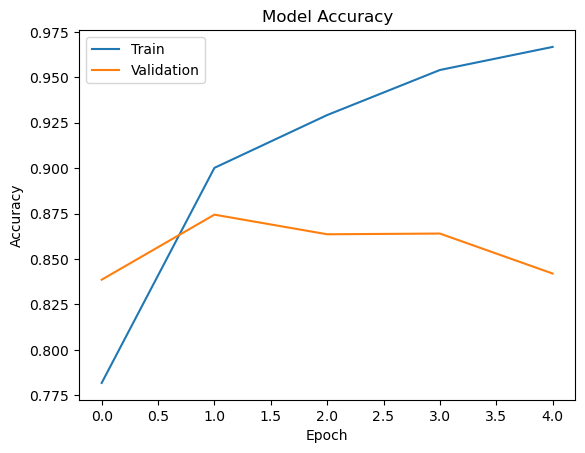

In [1]:
# 1. Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# 2. Load Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# 3. Preprocessing (Padding)
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# 4. Build LSTM Model
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

# 5. Compile Model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 6. Train Model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# 7. Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# 8. Plot Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()